<a href="https://colab.research.google.com/github/Soham86/Projects/blob/main/Trading_DQN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
pip install gymnasium numpy pandas torch yfinance matplotlib

In [4]:
"""Project structure :-
   1.Stock Environment - custom gym environment
   2.DQN Agent - DQN agent with exerience replay
   3.Training loop
   4.Evaluation and Plotting """

'Project structure :- \n   1.Stock Environment - custom gym environment \n   2.DQN Agent - DQN agent with exerience replay\n   3.Training loop \n   4.Evaluation and Plotting '

##importing the Libraries

In [5]:
import numpy as np
import pandas as pd
import gymnasium as gym
from gymnasium import spaces
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque
import yfinance as yf
import matplotlib.pyplot as plt

##Let's create the Custom Environment for our agent

In [6]:
#--------------------------
#   1.Stock Environment
#--------------------------

In [92]:
import gym
from gym import spaces
import numpy as np
import yfinance as yf

class StockEnv(gym.Env):
    def __init__(self, ticker="AAPL", window_size=10, initial_balance=10000):
        super(StockEnv, self).__init__()
        self.ticker = ticker
        self.window_size = window_size
        self.initial_balance = initial_balance

        self.data = yf.download(ticker, start="2020-01-01", end="2024-01-01")
        if len(self.data) < window_size + 1:
            raise ValueError("Not enough data for the window_size")

        self.data["norm_close"] = self.data["Close"] / self.data["Close"].iloc[0]
        self.data["norm_volume"] = self.data["Volume"] / self.data["Volume"].max()

        self.action_space = spaces.Discrete(3)
        obs_dim = 2 * window_size + 2
        self.observation_space = spaces.Box(low=-1, high=2, shape=(obs_dim,), dtype=np.float32)

        self.total_steps = len(self.data) - 1
        self.reset()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.step_count = self.window_size
        self.balance = self.initial_balance
        self.position = 0

        obs = self._get_obs()
        return obs, {}

    def _get_obs(self):
        start = self.step_count - self.window_size
        end = self.step_count

        # 1. Extract values and ensure they are 1D arrays
        close_seq = self.data["norm_close"].iloc[start:end].values.flatten()
        volume_seq = self.data["norm_volume"].iloc[start:end].values.flatten()

        # 2. Convert to raw floats to avoid "inhomogeneous shape" errors
        pos_val = float(self.position / 100)
        bal_val = float(self.balance / self.initial_balance)

        # 3. Concatenate and cast to float32 for the Neural Network
        obs = np.concatenate((close_seq, volume_seq, [pos_val, bal_val]))
        return obs.astype(np.float32)

    def step(self, action):
        # Extract scalar price
        current_price = float(self.data["Close"].iloc[self.step_count].item())
        prev_portfolio_value = self.balance + (self.position * current_price)

        if action == 0:  # Sell
            self.balance += current_price * self.position
            self.position = 0
        elif action == 2:  # Buy
            shares_to_buy = int(self.balance // current_price)
            if shares_to_buy > 0:
                self.position += shares_to_buy
                self.balance -= shares_to_buy * current_price

        self.step_count += 1
        done = self.step_count >= self.total_steps

        new_price = float(self.data["Close"].iloc[self.step_count].item())
        portfolio_value = self.balance + (self.position * new_price)
        reward = (portfolio_value - prev_portfolio_value) / prev_portfolio_value

        # Ensure 'portfolio_value' is a float, NOT a series
        return self._get_obs(), float(reward), done, False, {"portfolio_value": float(portfolio_value)}

## Let's Create our DQN agent

In [93]:
#--------------------------
#   2.DQN Agent
#--------------------------

In [94]:
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque

class DQNAgent:
    def __init__(self, state_dim, action_dim, lr=1e-3, gamma=0.99,
                 epsilon_start=1.0, epsilon_end=0.05, epsilon_decay=0.995,
                 replay_size=10000, batch_size=64, target_update=10):
        self.action_dim = action_dim
        self.gamma = gamma
        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay
        self.batch_size = batch_size
        self.target_update = target_update

        self.policy_net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim)
        )
        self.target_net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim)
        )
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)
        self.replay_buffer = deque(maxlen=replay_size)
        self.steps = 0

    def select_action(self, state):
        if random.random() < self.epsilon:
            return random.randint(0, self.action_dim - 1)
        else:
            with torch.no_grad():
                state_tensor = torch.FloatTensor(state).unsqueeze(0)
                q_values = self.policy_net(state_tensor)
                return q_values.max(1)[1].item()

    def store_transition(self, state, action, reward, next_state, done):
        self.replay_buffer.append((state, action, reward, next_state, done))

    def train(self):
        if len(self.replay_buffer) < self.batch_size:
            return None

        batch = random.sample(self.replay_buffer, self.batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        states = torch.FloatTensor(np.array(states))
        actions = torch.LongTensor(actions).unsqueeze(1)
        rewards = torch.FloatTensor(rewards).unsqueeze(1)
        next_states = torch.FloatTensor(np.array(next_states))
        dones = torch.FloatTensor(dones).unsqueeze(1)

        # Current Q-values
        q_values = self.policy_net(states).gather(1, actions)

        # Target Q-values
        with torch.no_grad():
            next_q = self.target_net(next_states).max(1, keepdim=True)[0]
            target_q = rewards + (1 - dones) * self.gamma * next_q

        loss = nn.MSELoss()(q_values, target_q)

        # FIXES: Corrected typos here
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        # Decay epsilon
        if self.epsilon > self.epsilon_end:
            self.epsilon *= self.epsilon_decay

        # Update target network
        self.steps += 1
        if self.steps % self.target_update == 0:
            self.target_net.load_state_dict(self.policy_net.state_dict())

        return loss.item()

## Training Loop

In [95]:
#--------------------------
#   3.Training Loop
#--------------------------

In [96]:
def train(self):
        if len(self.replay_buffer) < self.batch_size:
            return None

        batch = random.sample(self.replay_buffer, self.batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        # Convert to numpy arrays first, then to torch tensors
        states = torch.FloatTensor(np.array(states))
        actions = torch.LongTensor(actions).unsqueeze(1)
        # Flatten rewards: use np.array(rewards) to ensure it's a simple list of floats
        rewards = torch.FloatTensor(np.array(rewards)).unsqueeze(1)
        next_states = torch.FloatTensor(np.array(next_states))
        dones = torch.FloatTensor(np.array(dones)).unsqueeze(1)

        q_values = self.policy_net(states).gather(1, actions)

        with torch.no_grad():
            next_q = self.target_net(next_states).max(1, keepdim=True)[0]
            target_q = rewards + (1 - dones) * self.gamma * next_q

        loss = nn.MSELoss()(q_values, target_q)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        if self.epsilon > self.epsilon_end:
            self.epsilon *= self.epsilon_decay

        self.steps += 1
        if self.steps % self.target_update == 0:
            self.target_net.load_state_dict(self.policy_net.state_dict())

        return loss.item()

## Let's plot the Reward

In [97]:
def plot_results(rewards, portfolios):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(rewards)
    plt.title("Episode Rewards")
    plt.xlabel("Episode")
    plt.ylabel("Reward")

    plt.subplot(1, 2, 2)
    plt.plot(portfolios)
    plt.title("Final Portfolio Value per Episode")
    plt.xlabel("Episode")
    plt.ylabel("Portfolio Value")

    plt.tight_layout()
    plt.show()

## Starting the Agent

/tmp/ipykernel_3478/2353463182.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  self.data = yf.download(ticker, start="2020-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Episode 10/200, Reward: 0.89, Portfolio: 23113.12, Epsilon: 0.050
Episode 20/200, Reward: 1.27, Portfolio: 33484.87, Epsilon: 0.050
Episode 30/200, Reward: 1.24, Portfolio: 32760.56, Epsilon: 0.050
Episode 40/200, Reward: 0.87, Portfolio: 22965.47, Epsilon: 0.050
Episode 50/200, Reward: 1.42, Portfolio: 39255.65, Epsilon: 0.050
Episode 60/200, Reward: 1.69, Portfolio: 51666.55, Epsilon: 0.050
Episode 70/200, Reward: 1.46, Portfolio: 40688.48, Epsilon: 0.050
Episode 80/200, Reward: 1.59, Portfolio: 46958.60, Epsilon: 0.050
Episode 90/200, Reward: 1.69, Portfolio: 50779.09, Epsilon: 0.050
Episode 100/200, Reward: 1.35, Portfolio: 35909.86, Epsilon: 0.050
Episode 110/200, Reward: 1.54, Portfolio: 44198.16, Epsilon: 0.050
Episode 120/200, Reward: 1.74, Portfolio: 53435.10, Epsilon: 0.050
Episode 130/200, Reward: 1.32, Portfolio: 35907.66, Epsilon: 0.050
Episode 140/200, Reward: 1.83, Portfolio: 59059.25, Epsilon: 0.050
Episode 150/200, Reward: 1.77, Portfolio: 55794.78, Epsilon: 0.050
Epis

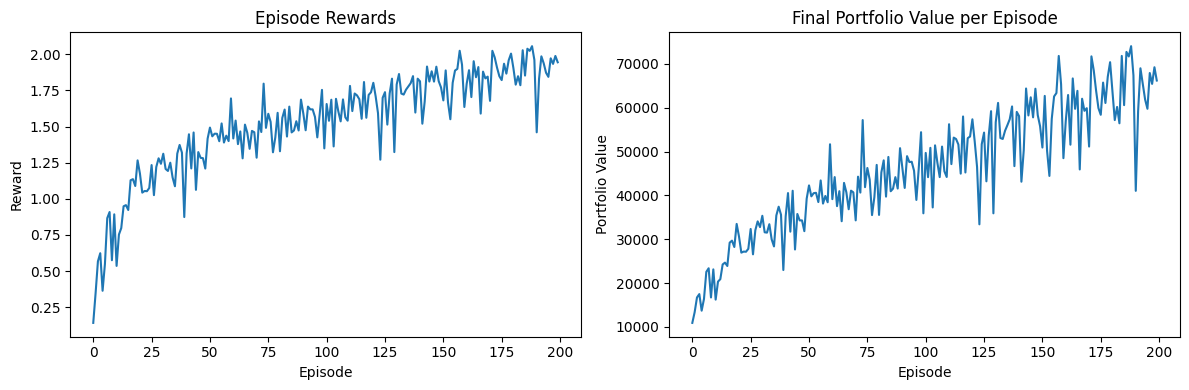

In [98]:

if __name__ == "__main__":
    env, agent, rewards, portfolios = train_dqn(ticker="AAPL", num_episodes=200)
    plot_results(rewards, portfolios)